<a href="https://colab.research.google.com/github/YenlingPeng/T-Brain_AI_esunbank/blob/Ying/fraud_detection_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 警示帳戶預測 - 機器學習模型
## 使用交易資料預測帳戶是否為警示帳戶

### 步驟說明：
1. 上傳資料檔案
2. 資料清洗與前處理
3. 特徵工程
4. 模型訓練
5. 模型評估
6. 預測結果

## 1. 安裝與載入套件

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import warnings
from google.colab import files
warnings.filterwarnings('ignore')

print("✓ 套件載入成功")

✓ 套件載入成功


## 2. 上傳資料檔案

請上傳以下三個CSV檔案：
- `acct_transaction.csv` - 交易資料
- `acct_alert.csv` - 警示帳戶清單
- `acct_predict.csv` - 待預測帳戶清單

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## 3. 讀取資料

In [ ]:
dir_path = "/content/drive/MyDrive/2025_alert_account/data"
# 讀取三個CSV檔案
df_transaction = pd.read_csv(os.path.join(dir_path, 'acct_transaction.csv'))
df_alert = pd.read_csv(os.path.join(dir_path, 'acct_alert.csv'))
df_predict = pd.read_csv(os.path.join(dir_path, 'acct_predict.csv'))

print("="*50)
print("資料讀取成功")
print("="*50)
print(f"交易資料筆數: {len(df_transaction):,}")
print(f"警示帳戶數: {len(df_alert):,}")
print(f"待預測帳戶數: {len(df_predict):,}")

# 查看資料前幾行
print("\n交易資料前5筆:")
display(df_transaction.head())

print("\n警示帳戶前5筆:")
display(df_alert.head())

print("\n待預測帳戶前5筆:")
display(df_predict.head())

資料讀取成功
交易資料筆數: 4,435,890
警示帳戶數: 1,004
待預測帳戶數: 4,780

交易資料前5筆:


,from_acct,from_acct_type,to_acct,to_acct_type,is_self_txn,txn_amt,txn_date,txn_time,currency_type,channel_type
0,be6fdd2d0f9aa02b0b09436fb137654942e3346e16ab43...,1,7abb16ac9bddc1f464981131ba68506775a964df2e0734...,1,N,47500.0,71,05:05:00,TWD,04
1,18f3d0e79217f8bc8b4cb485f9f80a884771b846de652f...,1,e77e425fb5f3ece7a7b431b3c43cc1d040f3054e35479d...,2,UNK,6150.0,31,20:55:00,TWD,03
2,302f3911cbf56bf9b5ad209a4b045a82380f98d92604c1...,1,4a707a0af2aa824777082803013610090033104c308023...,1,N,1150000.0,37,09:20:00,TWD,04
3,5a4809796865b1526f46e5dda6a35c1a4def3cbe969cc8...,1,d16b1bf33802f020b508002755c13aad549bc59dde7aae...,2,UNK,8550.0,106,13:40:00,TWD,04
4,7f84214987bdee16ffbaf3d70824e6385ce80e032a24c5...,1,c2e0f75b54f394b29755779ab9a488931e9d893a0e5f8f...,1,N,1450.0,84,11:20:00,TWD,03



警示帳戶前5筆:


,acct,event_date
0,80bd1c28b47357a3d37a01835ebb1bed5edf54e791bd3d...,87
1,b8c11db05d00b5ac66be10ffee5f6ce6ef9221c733a4bb...,19
2,daa05c68b290ac3cc522abad400c5304dffba07baa232c...,81
3,174e26ecc9cee56aaaca855c743a106275c58629740a49...,88
4,007cf5c98aa4f9f3e444c9cdaca74d0f7542e9a2804201...,117



待預測帳戶前5筆:


,acct,label
0,fcf31c5113d3dbd9cb5056045c6a0f213bd8a4fc1bc834...,0
1,e21dfa45e990364194468e501fbfe52ec02a4b71a2e2e8...,0
2,2552e943aaf9caa33183758cd40128ef20a6e6ff16c232...,0
3,71700e7b7c3d40abdfdbcc7afc0752fa8d9bd28b408651...,0
4,c70349fc718ffb88f03f31b5a7fcf65b33dd71dce6fee0...,0


## 4. 資料清洗與前處理

In [ ]:
print("\n" + "=" * 50)
print("資料清洗與前處理...")
print("=" * 50)

# 處理交易日期（數字格式，代表第幾天）
df_transaction['txn_date'] = pd.to_numeric(df_transaction['txn_date'], errors='coerce')

# 處理交易時間並提取特徵
df_transaction['txn_time'] = pd.to_datetime(df_transaction['txn_time'], format='%H:%M:%S', errors='coerce')
df_transaction['txn_hour'] = df_transaction['txn_time'].dt.hour

# 定義時段
def get_time_period(hour):
    if pd.isna(hour):
        return 'unknown'
    elif 0 <= hour < 6:
        return 'late_night'  # 深夜 00:00-06:00
    elif 6 <= hour < 12:
        return 'morning'     # 早上 06:00-12:00
    elif 12 <= hour < 18:
        return 'afternoon'   # 下午 12:00-18:00
    else:
        return 'evening'     # 晚上 18:00-24:00

df_transaction['time_period'] = df_transaction['txn_hour'].apply(get_time_period)

# 處理警示日期（如果也是數字格式）
if df_alert['event_date'].dtype == 'object':
    try:
        df_alert['event_date'] = pd.to_numeric(df_alert['event_date'], errors='coerce')
    except:
        df_alert['event_date'] = pd.to_datetime(df_alert['event_date'], errors='coerce')

# 處理 is_self_txn (Y/N/UNK -> 1/0/-1)
is_self_map = {'Y': 1, 'N': 0, 'UNK': -1}
df_transaction['is_self_txn_num'] = df_transaction['is_self_txn'].map(is_self_map).fillna(-1)

# 處理 from_acct_type 和 to_acct_type (01:玉山, 02:其他)
df_transaction['from_acct_type'] = df_transaction['from_acct_type'].astype(str).str.strip()
df_transaction['to_acct_type'] = df_transaction['to_acct_type'].astype(str).str.strip()

print("✓ 資料清洗完成")
print(f"  日期範圍: {df_transaction['txn_date'].min():.0f} ~ {df_transaction['txn_date'].max():.0f} 天")
print(f"  時間範圍: {df_transaction['txn_hour'].min():.0f}:00 ~ {df_transaction['txn_hour'].max():.0f}:00")


資料清洗與前處理...
✓ 資料清洗完成
  日期範圍: 1 ~ 121 天
  時間範圍: 0:00 ~ 23:00


In [ ]:
print("\n" + "=" * 50)
print("資料清洗與前處理...")
print("=" * 50)

# 處理交易日期（數字格式，代表第幾天）
df_transaction['txn_date'] = pd.to_numeric(df_transaction['txn_date'], errors='coerce')

# 處理交易時間並提取特徵
df_transaction['txn_time'] = pd.to_datetime(df_transaction['txn_time'], format='%H:%M:%S', errors='coerce')
df_transaction['txn_hour'] = df_transaction['txn_time'].dt.hour

# 定義時段
def get_time_period(hour):
    if pd.isna(hour):
        return 'unknown'
    elif 0 <= hour < 6:
        return 'late_night'  # 深夜 00:00-06:00
    elif 6 <= hour < 12:
        return 'morning'     # 早上 06:00-12:00
    elif 12 <= hour < 18:
        return 'afternoon'   # 下午 12:00-18:00
    else:
        return 'evening'     # 晚上 18:00-24:00

df_transaction['time_period'] = df_transaction['txn_hour'].apply(get_time_period)

# 處理警示日期（如果也是數字格式）
if df_alert['event_date'].dtype == 'object':
    try:
        df_alert['event_date'] = pd.to_numeric(df_alert['event_date'], errors='coerce')
    except:
        df_alert['event_date'] = pd.to_datetime(df_alert['event_date'], errors='coerce')

# 處理 is_self_txn (Y/N/UNK -> 1/0/-1)
is_self_map = {'Y': 1, 'N': 0, 'UNK': -1}
df_transaction['is_self_txn_num'] = df_transaction['is_self_txn'].map(is_self_map).fillna(-1)

# 處理 from_acct_type 和 to_acct_type (01:玉山, 02:其他)
# 先轉字串再補零，確保是兩位數
df_transaction['from_acct_type'] = df_transaction['from_acct_type'].astype(str).str.strip().str.zfill(2)
df_transaction['to_acct_type'] = df_transaction['to_acct_type'].astype(str).str.strip().str.zfill(2)

print("✓ 資料清洗完成")
print(f"  日期範圍: {df_transaction['txn_date'].min():.0f} ~ {df_transaction['txn_date'].max():.0f} 天")
print(f"  時間範圍: {df_transaction['txn_hour'].min():.0f}:00 ~ {df_transaction['txn_hour'].max():.0f}:00")

# 檢查帳戶類型分布
print(f"\n帳戶類型分布:")
print(f"  from_acct_type: {df_transaction['from_acct_type'].value_counts().to_dict()}")
print(f"  to_acct_type: {df_transaction['to_acct_type'].value_counts().to_dict()}")


資料清洗與前處理...
✓ 資料清洗完成
  日期範圍: 1 ~ 121 天
  時間範圍: 0:00 ~ 23:00

帳戶類型分布:
  from_acct_type: {'01': 2988819, '02': 1447071}
  to_acct_type: {'01': 2404671, '02': 2031219}


## 5. 特徵工程

In [ ]:
print("\n" + "=" * 50)
print("特徵工程...")
print("=" * 50)

def create_features(df_trans, account_col='from_acct'):
    """
    為每個帳戶創建特徵（優化版，適合大量資料）
    """
    features = {}

    # 針對指定的帳戶欄位進行分組
    grouped = df_trans.groupby(account_col)

    # === 基本統計特徵 ===
    features[f'{account_col}_txn_count'] = grouped.size()  # 交易次數
    features[f'{account_col}_total_amt'] = grouped['txn_amt'].sum()  # 總交易金額
    features[f'{account_col}_avg_amt'] = grouped['txn_amt'].mean()  # 平均交易金額
    features[f'{account_col}_max_amt'] = grouped['txn_amt'].max()  # 最大交易金額
    features[f'{account_col}_min_amt'] = grouped['txn_amt'].min()  # 最小交易金額
    features[f'{account_col}_std_amt'] = grouped['txn_amt'].std().fillna(0)  # 交易金額標準差
    features[f'{account_col}_median_amt'] = grouped['txn_amt'].median()  # 中位數金額

    # === 交易時間特徵 ===
    features[f'{account_col}_unique_dates'] = grouped['txn_date'].nunique()  # 交易天數
    features[f'{account_col}_date_range'] = grouped['txn_date'].apply(lambda x: x.max() - x.min() if len(x) > 1 else 0)  # 交易日期跨度
    features[f'{account_col}_avg_txn_per_day'] = (
        grouped.size() / grouped['txn_date'].nunique()
    )  # 平均每天交易次數

    # === 時段特徵 ===
    features[f'{account_col}_late_night_ratio'] = (
        grouped['time_period'].apply(lambda x: (x == 'late_night').sum() / len(x))
    )  # 深夜交易比例
    features[f'{account_col}_morning_ratio'] = (
        grouped['time_period'].apply(lambda x: (x == 'morning').sum() / len(x))
    )  # 早上交易比例
    features[f'{account_col}_afternoon_ratio'] = (
        grouped['time_period'].apply(lambda x: (x == 'afternoon').sum() / len(x))
    )  # 下午交易比例
    features[f'{account_col}_evening_ratio'] = (
        grouped['time_period'].apply(lambda x: (x == 'evening').sum() / len(x))
    )  # 晚上交易比例

    # === 交易通路特徵 ===
    features[f'{account_col}_unique_channels'] = grouped['channel_type'].nunique()  # 使用的通路數

    # === 交易對象特徵 ===
    if account_col == 'from_acct':
        features[f'{account_col}_unique_recipients'] = grouped['to_acct'].nunique()  # 收款帳戶數
        features[f'{account_col}_recipient_concentration'] = (
            grouped['to_acct'].nunique() / grouped.size()
        )  # 收款帳戶集中度
    else:
        features[f'{account_col}_unique_senders'] = grouped['from_acct'].nunique()  # 匯款帳戶數
        features[f'{account_col}_sender_concentration'] = (
            grouped['from_acct'].nunique() / grouped.size()
        )  # 匯款帳戶集中度

    # === 自己轉帳特徵 ===
    features[f'{account_col}_self_txn_ratio'] = (
        grouped['is_self_txn_num'].apply(lambda x: (x == 1).sum() / len(x))
    )  # 自己轉帳比例
    features[f'{account_col}_self_txn_count'] = (
        grouped['is_self_txn_num'].apply(lambda x: (x == 1).sum())
    )  # 自己轉帳次數

    # === 幣別特徵 ===
    features[f'{account_col}_foreign_currency_ratio'] = (
        grouped['currency_type'].apply(lambda x: (x != 'TWD').sum() / len(x))
    )  # 外幣交易比例
    features[f'{account_col}_unique_currencies'] = grouped['currency_type'].nunique()  # 使用幣別數

    # === 金額分佈特徵 ===
    # 大額交易（>100萬）比例
    features[f'{account_col}_large_txn_ratio'] = (
        grouped['txn_amt'].apply(lambda x: (x > 1000000).sum() / len(x))
    )
    # 小額交易（<1000）比例
    features[f'{account_col}_small_txn_ratio'] = (
        grouped['txn_amt'].apply(lambda x: (x < 1000).sum() / len(x))
    )

    # 轉換為DataFrame
    feature_df = pd.DataFrame(features)
    feature_df.index.name = 'acct'
    feature_df = feature_df.reset_index()

    return feature_df

# 創建匯款帳戶特徵（主要特徵）
print("創建匯款帳戶特徵...")
features_from = create_features(df_transaction, 'from_acct')

# 創建收款帳戶特徵（次要特徵）
print("創建收款帳戶特徵...")
features_to = create_features(df_transaction, 'to_acct')

# 合併特徵（只考慮玉山帳戶，from_acct_type='01' 或 to_acct_type='01'）
yushan_from = df_transaction[df_transaction['from_acct_type'] == '01']['from_acct'].unique()
yushan_to = df_transaction[df_transaction['to_acct_type'] == '01']['to_acct'].unique()
all_yushan_accts = pd.DataFrame({
    'acct': np.unique(np.concatenate([yushan_from, yushan_to]))
})

# 合併特徵
features_combined = all_yushan_accts.merge(features_from, on='acct', how='left')
features_combined = features_combined.merge(
    features_to,
    on='acct',
    how='left',
    suffixes=('_from', '_to')
)

# 填充缺失值
features_combined = features_combined.fillna(0)

print(f"✓ 特徵工程完成，共產生 {len(features_combined)} 個帳戶，{len(features_combined.columns)-1} 個特徵")


特徵工程...
創建匯款帳戶特徵...
創建收款帳戶特徵...
✓ 特徵工程完成，共產生 0 個帳戶，46 個特徵


In [ ]:
print("\n" + "=" * 50)
print("特徵工程...")
print("=" * 50)

def create_features(df_trans, account_col='from_acct'):
    """
    為每個帳戶創建特徵（優化版，適合大量資料）
    """
    features = {}

    # 針對指定的帳戶欄位進行分組
    grouped = df_trans.groupby(account_col)

    # === 基本統計特徵 ===
    features[f'{account_col}_txn_count'] = grouped.size()  # 交易次數
    features[f'{account_col}_total_amt'] = grouped['txn_amt'].sum()  # 總交易金額
    features[f'{account_col}_avg_amt'] = grouped['txn_amt'].mean()  # 平均交易金額
    features[f'{account_col}_max_amt'] = grouped['txn_amt'].max()  # 最大交易金額
    features[f'{account_col}_min_amt'] = grouped['txn_amt'].min()  # 最小交易金額
    features[f'{account_col}_std_amt'] = grouped['txn_amt'].std().fillna(0)  # 交易金額標準差
    features[f'{account_col}_median_amt'] = grouped['txn_amt'].median()  # 中位數金額

    # === 交易時間特徵 ===
    features[f'{account_col}_unique_dates'] = grouped['txn_date'].nunique()  # 交易天數
    features[f'{account_col}_date_range'] = grouped['txn_date'].apply(lambda x: x.max() - x.min() if len(x) > 1 else 0)  # 交易日期跨度
    features[f'{account_col}_avg_txn_per_day'] = (
        grouped.size() / grouped['txn_date'].nunique()
    )  # 平均每天交易次數

    # === 時段特徵 ===
    features[f'{account_col}_late_night_ratio'] = (
        grouped['time_period'].apply(lambda x: (x == 'late_night').sum() / len(x))
    )  # 深夜交易比例
    features[f'{account_col}_morning_ratio'] = (
        grouped['time_period'].apply(lambda x: (x == 'morning').sum() / len(x))
    )  # 早上交易比例
    features[f'{account_col}_afternoon_ratio'] = (
        grouped['time_period'].apply(lambda x: (x == 'afternoon').sum() / len(x))
    )  # 下午交易比例
    features[f'{account_col}_evening_ratio'] = (
        grouped['time_period'].apply(lambda x: (x == 'evening').sum() / len(x))
    )  # 晚上交易比例

    # === 交易通路特徵 ===
    features[f'{account_col}_unique_channels'] = grouped['channel_type'].nunique()  # 使用的通路數

    # === 交易對象特徵 ===
    if account_col == 'from_acct':
        features[f'{account_col}_unique_recipients'] = grouped['to_acct'].nunique()  # 收款帳戶數
        features[f'{account_col}_recipient_concentration'] = (
            grouped['to_acct'].nunique() / grouped.size()
        )  # 收款帳戶集中度
    else:
        features[f'{account_col}_unique_senders'] = grouped['from_acct'].nunique()  # 匯款帳戶數
        features[f'{account_col}_sender_concentration'] = (
            grouped['from_acct'].nunique() / grouped.size()
        )  # 匯款帳戶集中度

    # === 自己轉帳特徵 ===
    features[f'{account_col}_self_txn_ratio'] = (
        grouped['is_self_txn_num'].apply(lambda x: (x == 1).sum() / len(x))
    )  # 自己轉帳比例
    features[f'{account_col}_self_txn_count'] = (
        grouped['is_self_txn_num'].apply(lambda x: (x == 1).sum())
    )  # 自己轉帳次數

    # === 幣別特徵 ===
    features[f'{account_col}_foreign_currency_ratio'] = (
        grouped['currency_type'].apply(lambda x: (x != 'TWD').sum() / len(x))
    )  # 外幣交易比例
    features[f'{account_col}_unique_currencies'] = grouped['currency_type'].nunique()  # 使用幣別數

    # === 金額分佈特徵 ===
    # 大額交易（>100萬）比例
    features[f'{account_col}_large_txn_ratio'] = (
        grouped['txn_amt'].apply(lambda x: (x > 1000000).sum() / len(x))
    )
    # 小額交易（<1000）比例
    features[f'{account_col}_small_txn_ratio'] = (
        grouped['txn_amt'].apply(lambda x: (x < 1000).sum() / len(x))
    )

    # 轉換為DataFrame
    feature_df = pd.DataFrame(features)
    feature_df.index.name = 'acct'
    feature_df = feature_df.reset_index()

    return feature_df

# 創建匯款帳戶特徵（主要特徵）
print("創建匯款帳戶特徵...")
features_from = create_features(df_transaction, 'from_acct')

# 創建收款帳戶特徵（次要特徵）
print("創建收款帳戶特徵...")
features_to = create_features(df_transaction, 'to_acct')

# 合併特徵（只考慮玉山帳戶，from_acct_type='01' 或 to_acct_type='01'）
print("\n識別玉山帳戶...")
print(f"  from_acct_type='01' 的交易: {(df_transaction['from_acct_type'] == '01').sum():,} 筆")
print(f"  to_acct_type='01' 的交易: {(df_transaction['to_acct_type'] == '01').sum():,} 筆")

yushan_from = df_transaction[df_transaction['from_acct_type'] == '01']['from_acct'].unique()
yushan_to = df_transaction[df_transaction['to_acct_type'] == '01']['to_acct'].unique()

print(f"  玉山匯款帳戶數: {len(yushan_from):,}")
print(f"  玉山收款帳戶數: {len(yushan_to):,}")

all_yushan_accts = pd.DataFrame({
    'acct': np.unique(np.concatenate([yushan_from, yushan_to]))
})

print(f"  合計玉山帳戶數: {len(all_yushan_accts):,}")

# 合併特徵
features_combined = all_yushan_accts.merge(features_from, on='acct', how='left')
features_combined = features_combined.merge(
    features_to,
    on='acct',
    how='left',
    suffixes=('_from', '_to')
)

# 填充缺失值
features_combined = features_combined.fillna(0)

print(f"\n✓ 特徵工程完成")
print(f"  最終帳戶數: {len(features_combined):,}")
print(f"  特徵數: {len(features_combined.columns)-1}")


特徵工程...
創建匯款帳戶特徵...
創建收款帳戶特徵...

識別玉山帳戶...
  from_acct_type='01' 的交易: 2,988,819 筆
  to_acct_type='01' 的交易: 2,404,671 筆
  玉山匯款帳戶數: 231,092
  玉山收款帳戶數: 201,472
  合計玉山帳戶數: 333,768

✓ 特徵工程完成
  最終帳戶數: 333,768
  特徵數: 46


## 6. 準備訓練資料

In [ ]:
print("\n" + "=" * 50)
print("準備訓練資料...")
print("=" * 50)

# 創建標籤：警示帳戶為1，其他為0
alert_accts = set(df_alert['acct'].unique())
features_combined['label'] = features_combined['acct'].apply(
    lambda x: 1 if x in alert_accts else 0
)

print(f"警示帳戶數: {features_combined['label'].sum():,}")
print(f"非警示帳戶數: {(features_combined['label'] == 0).sum():,}")
print(f"警示帳戶比例: {features_combined['label'].mean():.2%}")

# 分離特徵和標籤
X = features_combined.drop(['acct', 'label'], axis=1)
y = features_combined['label']

# 切分訓練集和測試集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n訓練集大小: {len(X_train):,}")
print(f"測試集大小: {len(X_test):,}")


準備訓練資料...
警示帳戶數: 1,004
非警示帳戶數: 332,764
警示帳戶比例: 0.30%

訓練集大小: 267,014
測試集大小: 66,754


## 7. 訓練模型

In [ ]:

print("\n" + "=" * 50)
print("訓練模型...")
print("=" * 50)

# 使用隨機森林分類器（針對不平衡資料優化）
model = RandomForestClassifier(
    n_estimators=200,          # 增加樹的數量以提高穩定性
    max_depth=15,              # 適度增加深度
    min_samples_split=5,       # 避免過擬合
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced',   # 處理類別不平衡
    n_jobs=-1,                 # 使用所有CPU核心
    max_features='sqrt'        # 每次分裂考慮的特徵數
)

print("模型參數:")
print(f"  - 決策樹數量: 200")
print(f"  - 最大深度: 15")
print(f"  - 類別權重: balanced (自動處理不平衡)")
print("\n開始訓練...")

model.fit(X_train, y_train)
print("✓ 模型訓練完成")


訓練模型...
模型參數:
  - 決策樹數量: 200
  - 最大深度: 15
  - 類別權重: balanced (自動處理不平衡)

開始訓練...
✓ 模型訓練完成


## 8. 模型評估

In [ ]:
# 預測測試集
y_pred = model.predict(X_test)

# 計算F1 Score
f1 = f1_score(y_test, y_pred)
print("="*50)
print(f"F1 Score: {f1:.4f}")
print("="*50)

# 顯示分類報告
print("\n分類報告:")
print(classification_report(y_test, y_pred, target_names=['非警示帳戶', '警示帳戶']))

# 混淆矩陣
print("\n混淆矩陣:")
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=['實際非警示', '實際警示'],
    columns=['預測非警示', '預測警示']
)
display(cm_df)

F1 Score: 0.3618

分類報告:
              precision    recall  f1-score   support

       非警示帳戶       1.00      0.99      1.00     66553
        警示帳戶       0.24      0.70      0.36       201

    accuracy                           0.99     66754
   macro avg       0.62      0.85      0.68     66754
weighted avg       1.00      0.99      0.99     66754


混淆矩陣:


,預測非警示,預測警示
實際非警示,66120,433
實際警示,61,140


## 9. 特徵重要性分析

前15個重要特徵:


,feature,importance
32,to_acct_avg_txn_per_day,0.134058
38,to_acct_unique_senders,0.131671
39,to_acct_sender_concentration,0.086462
31,to_acct_date_range,0.072806
8,from_acct_date_range,0.049713
23,to_acct_txn_count,0.049503
24,to_acct_total_amt,0.049443
28,to_acct_std_amt,0.047345
26,to_acct_max_amt,0.034480
25,to_acct_avg_amt,0.032612


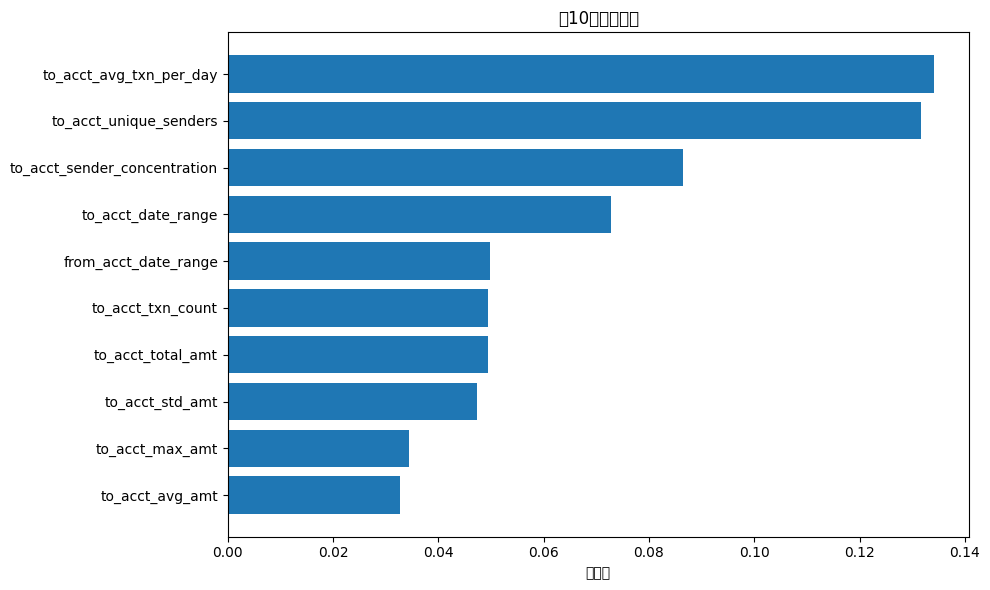

In [ ]:
# 特徵重要性
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("前15個重要特徵:")
display(feature_importance.head(15))

# 視覺化（可選）
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(range(10), feature_importance['importance'].head(10))
plt.yticks(range(10), feature_importance['feature'].head(10))
plt.xlabel('重要性')
plt.title('前10個重要特徵')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 10. 預測待測帳戶

In [ ]:
# 準備預測資料
predict_accts = df_predict['acct'].unique()
predict_features = features_combined[features_combined['acct'].isin(predict_accts)].copy()

if len(predict_features) > 0:
    X_predict = predict_features.drop(['acct', 'label'], axis=1)
    predictions = model.predict(X_predict)

    # 將預測結果加入DataFrame
    predict_features['predicted_label'] = predictions

    # 選擇需要的欄位
    result = predict_features[['acct', 'predicted_label']].copy()
    result.columns = ['acct', 'label']

    # 儲存預測結果
    result.to_csv('acct_predict_result.csv', index=False)

    print("="*50)
    print("預測完成")
    print("="*50)
    print(f"共預測 {len(result)} 個帳戶")
    print(f"預測為警示帳戶: {(result['label'] == 1).sum()}")
    print(f"預測為非警示帳戶: {(result['label'] == 0).sum()}")

    print("\n預測結果:")
    display(result)

    # 下載結果檔案
    print("\n下載預測結果...")
    files.download('acct_predict_result.csv')
else:
    print("找不到待預測帳戶的交易資料")

預測完成
共預測 4780 個帳戶
預測為警示帳戶: 128
預測為非警示帳戶: 4652

預測結果:


,acct,label
80,000ef1e36f55fd9f71dd7e02fe747af1f6240417f9e807...,0
98,00129e51dddd8e4265489bad36a7c1a66f813ee1c86a79...,0
153,001d6ee4c8bdfc61447fdb5624c57a897426e278ba10b9...,0
281,0036584bcfa9a386492e6538fc0c6ae0728f098d11e640...,0
346,0045920c6a09906468d855f0343972685d925000266ffb...,0
...,...,...
333468,ffc57164490ac42791c41d26da9111712eef174ff063ff...,0
333613,ffe38ad06b0156ca2bb4c4d7d7a98b8f845f884dcdcf58...,0
333695,fff3489c4033aded2822d46b603bc00677635ed9f04d4d...,0
333708,fff53cd9100e9a3f6e8d200969df0f3256524f15a80c7e...,0



下載預測結果...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 總結

### 模型效能
- 使用隨機森林分類器
- F1 Score 可在上方查看
- 支援類別不平衡處理（class_weight='balanced'）

### 改進建議
1. 調整模型參數（n_estimators, max_depth等）
2. 嘗試其他演算法（XGBoost, LightGBM等）
3. 增加更多特徵（交易時段、週期性等）
4. 處理類別不平衡（SMOTE等技術）
5. 交叉驗證提升穩定性